In [ ]:
%pip install numpy pandas matplotlib seaborn scipy imbalanced-learn xgboost

In [38]:
# Let's import the relevant data science libraries.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats

In [ ]:
# Let's load our csv file.

df = pd.read_csv("bank-full.csv")

In [8]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Data Cleaning

In [9]:
df.drop_duplicates()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
# Let's check for the null values (amazingly, there aren't any!!)
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [ ]:
# Let's identify the categorical fields

df.select_dtypes(include = "object")

C:\Users\Cyrus\AppData\Local\Temp\ipykernel_10168\1155783615.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include = "object")


,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,management,married,tertiary,no,yes,no,unknown,may,unknown,no
1,technician,single,secondary,no,yes,no,unknown,may,unknown,no
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,no
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,no
4,unknown,single,unknown,no,no,no,unknown,may,unknown,no
...,...,...,...,...,...,...,...,...,...,...
45206,technician,married,tertiary,no,no,no,cellular,nov,unknown,yes
45207,retired,divorced,primary,no,no,no,cellular,nov,unknown,yes
45208,retired,married,secondary,no,no,no,cellular,nov,success,yes
45209,blue-collar,married,secondary,no,no,no,telephone,nov,unknown,no


In [26]:
# Now let's identify the numerical fields

df.select_dtypes(exclude = "object")


,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0
...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0
45207,71,1729,17,456,2,-1,0
45208,72,5715,17,1127,5,184,3
45209,57,668,17,508,4,-1,0


In [16]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# Let's extract a new feature from 'age' for better visualization. This column will be categorical

df["age_group"] = ""

for i, row in df.iterrows():
    if row["age"] <= 35:
        df.at[i, "age_group"] = "young adult"
    elif row["age"] <= 50:
        df.at[i, "age_group"] = "middle-aged"
    else:
        df.at[i, "age_group"] = "senior"

In [23]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,age_group
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,senior
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,middle-aged
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,young adult
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,middle-aged
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,young adult


In [ ]:
# Let's examine the Pearson coefficients

df.corr(numeric_only=True)

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


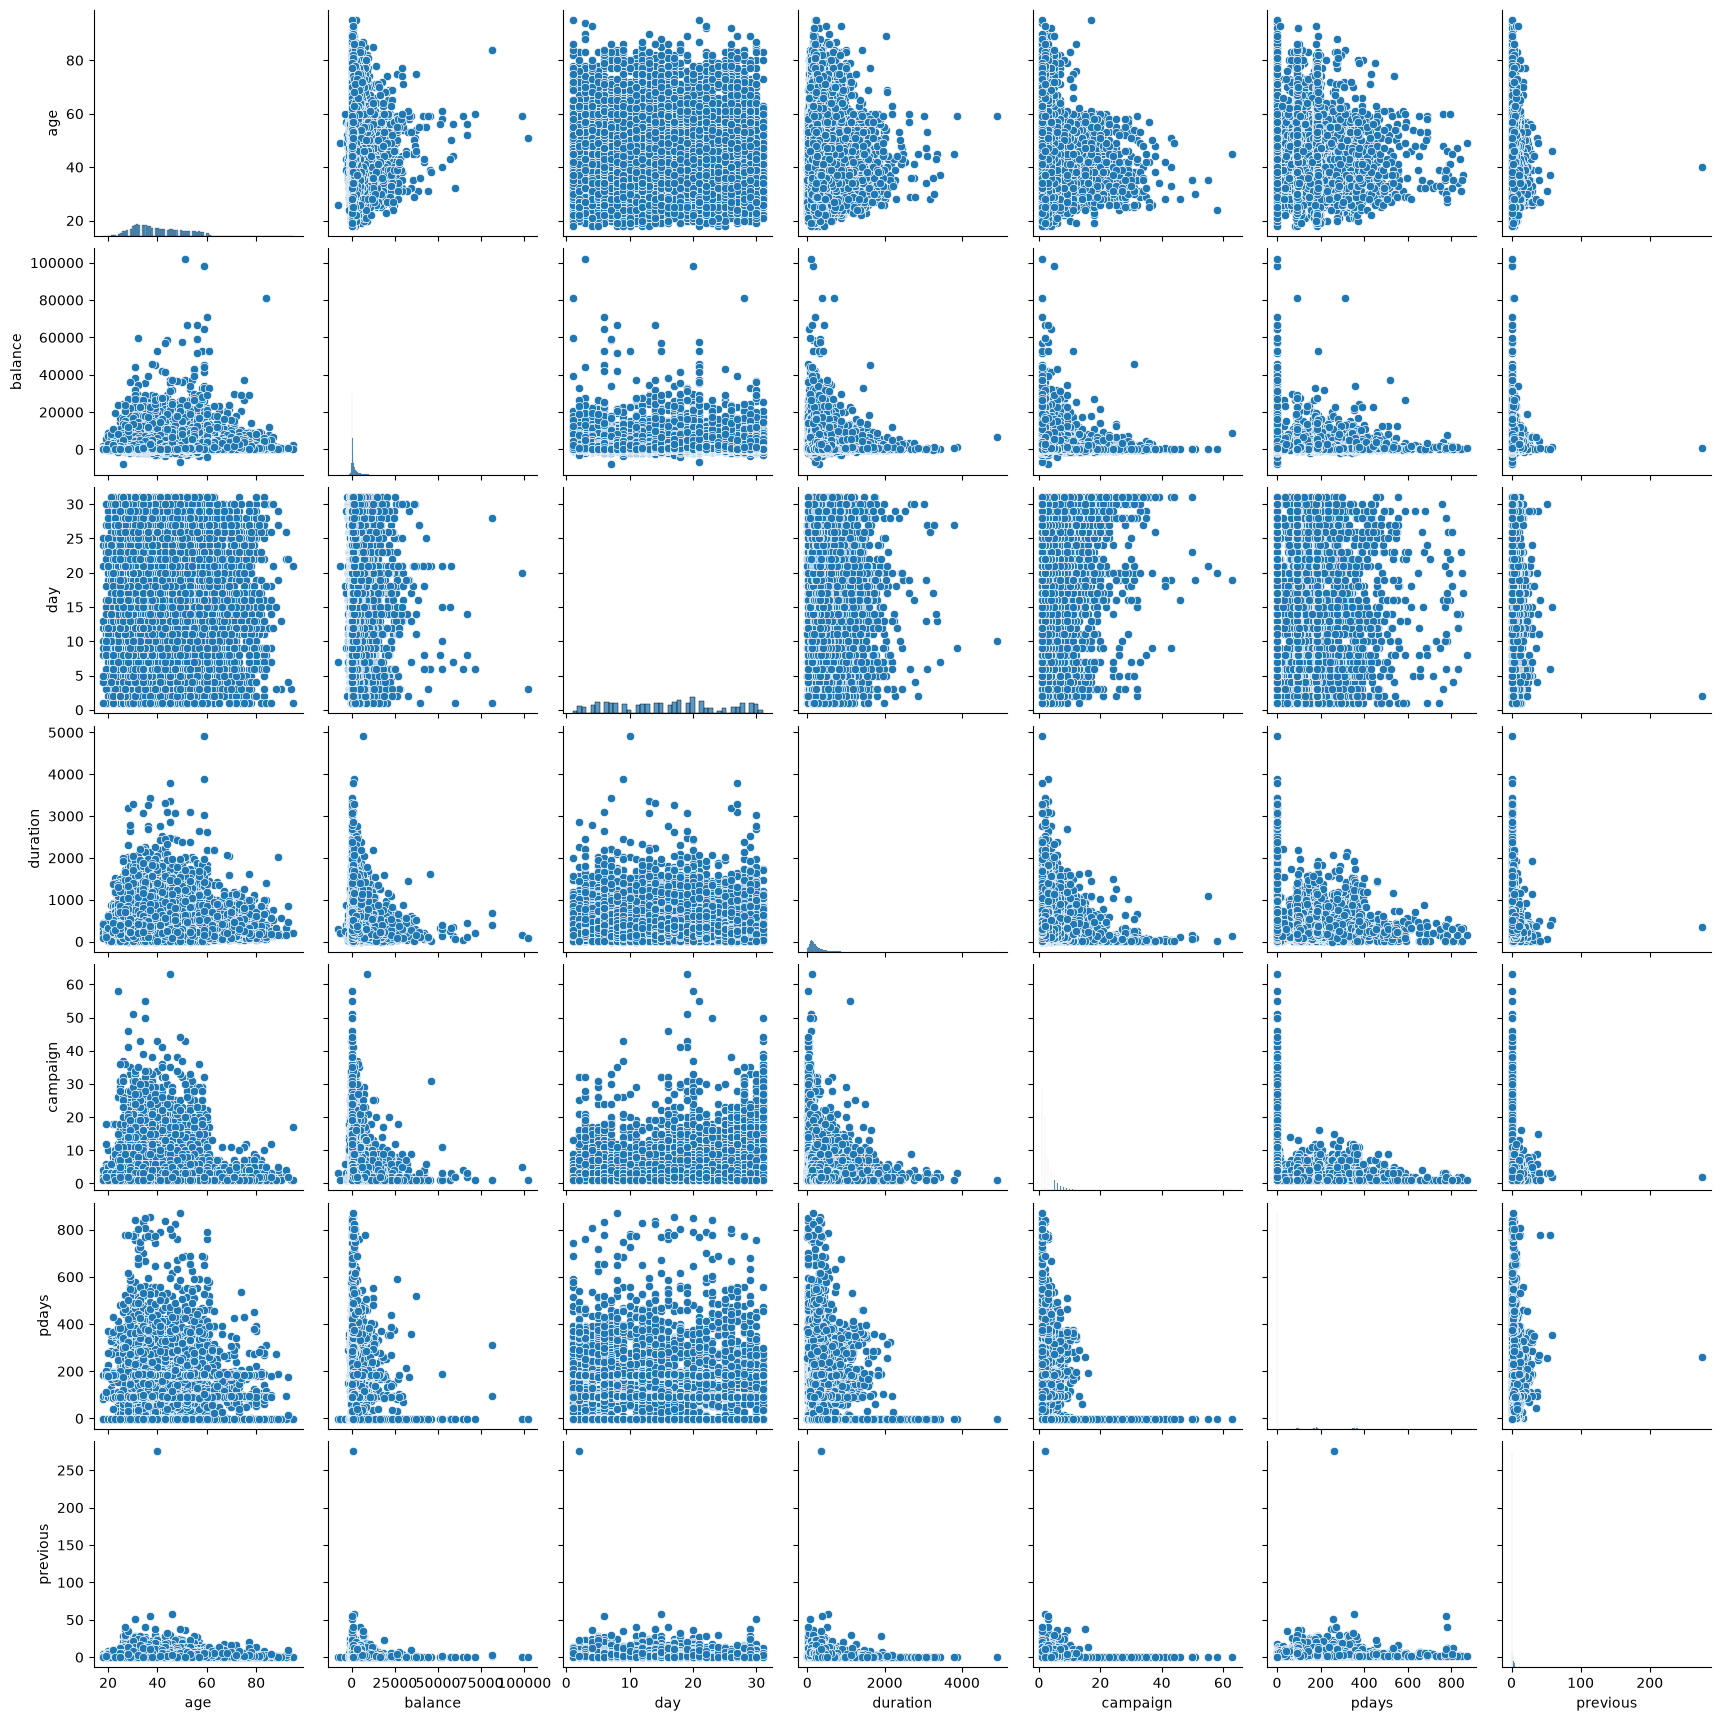

In [ ]:
# Let's graph these relationships
sns.pairplot(df)

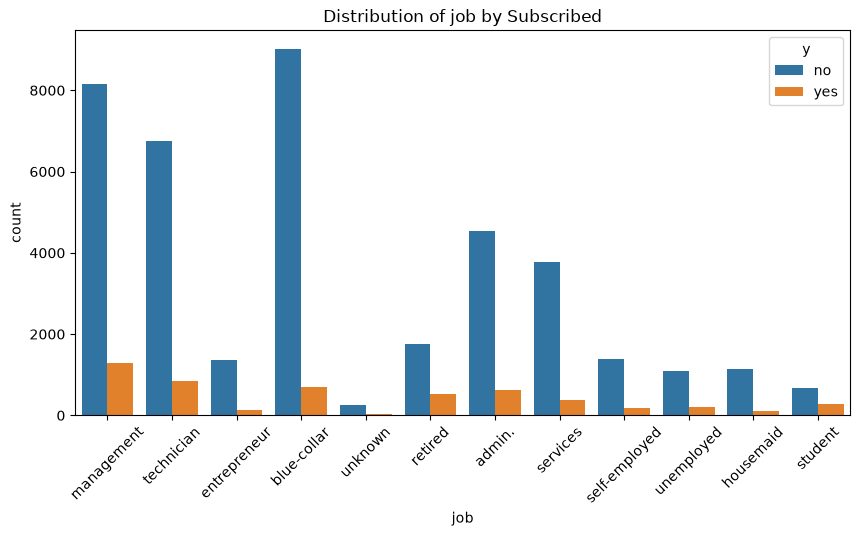

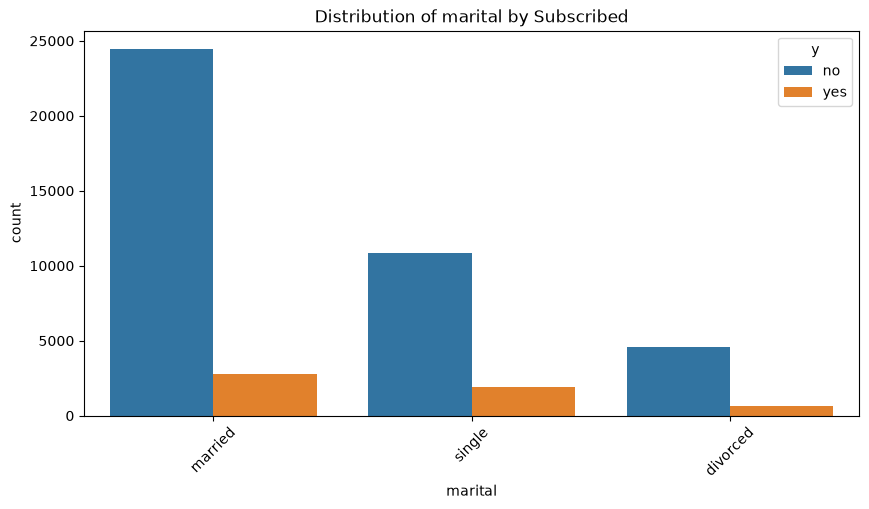

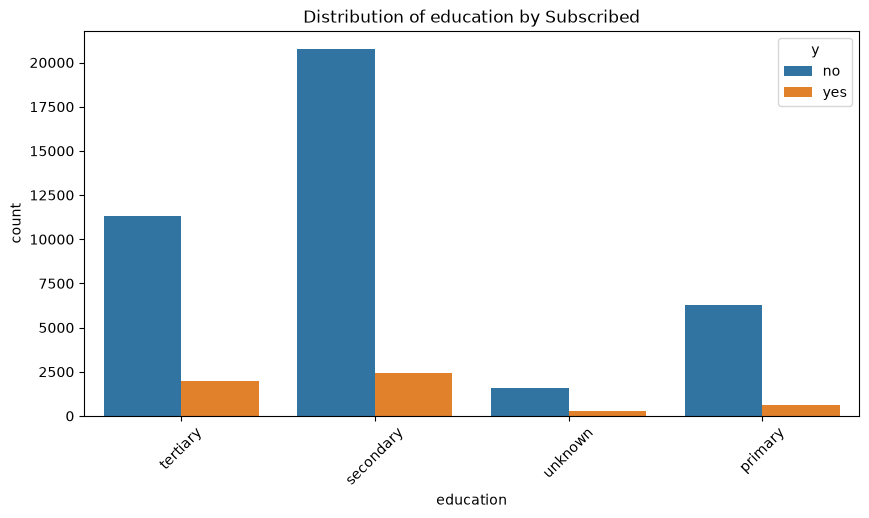

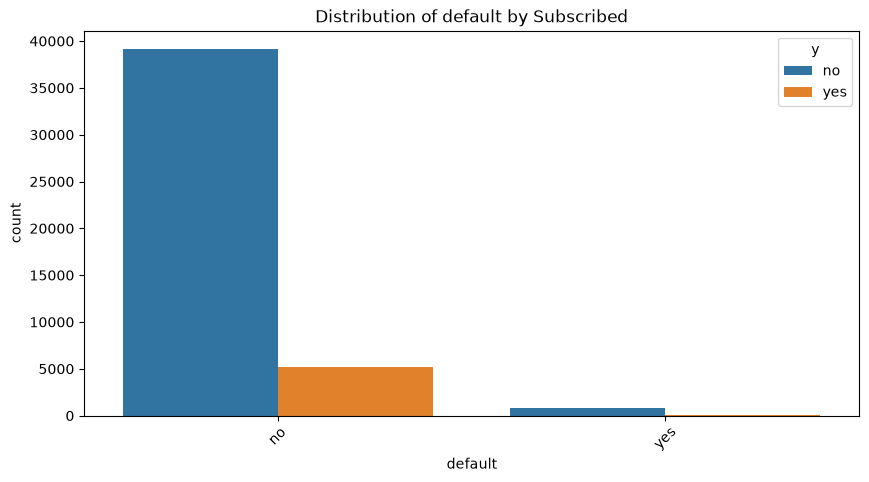

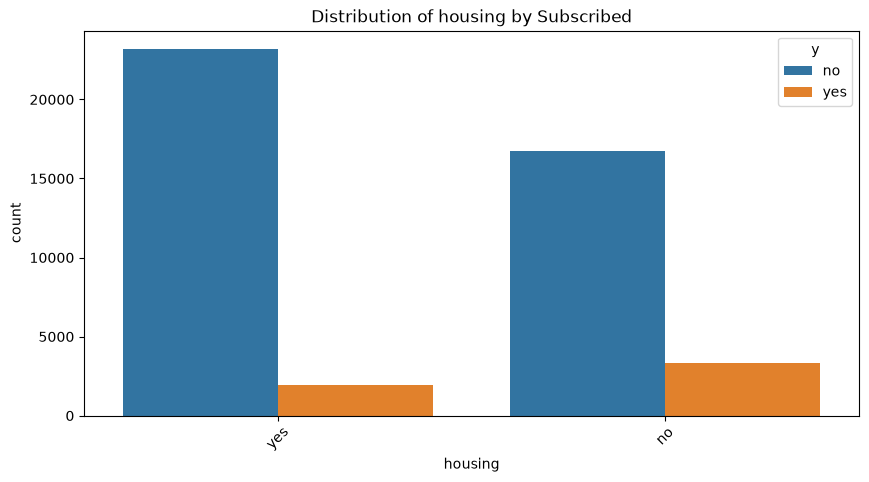

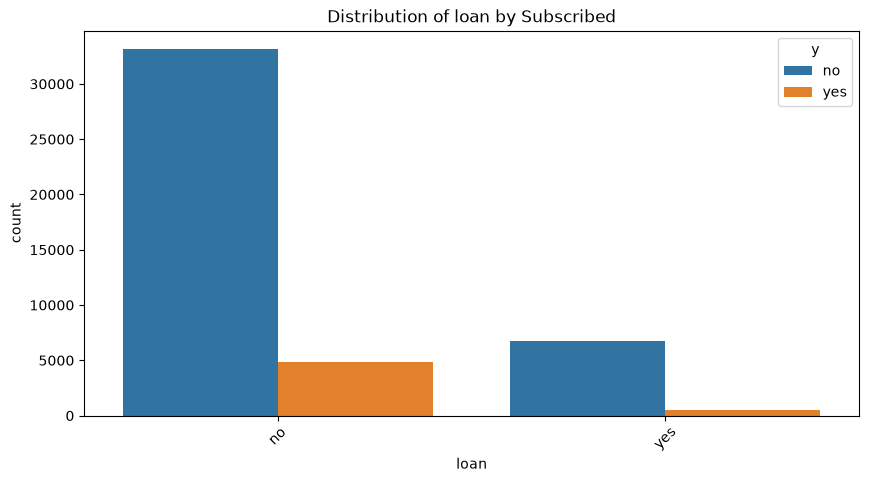

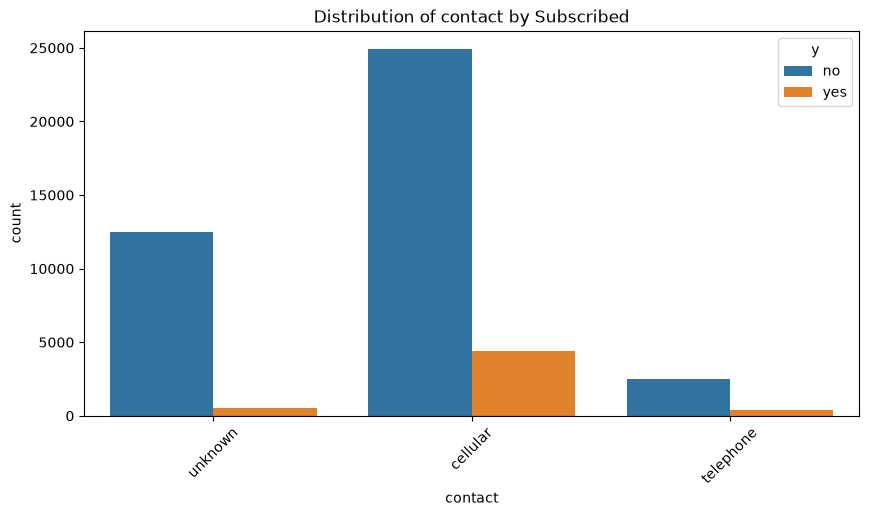

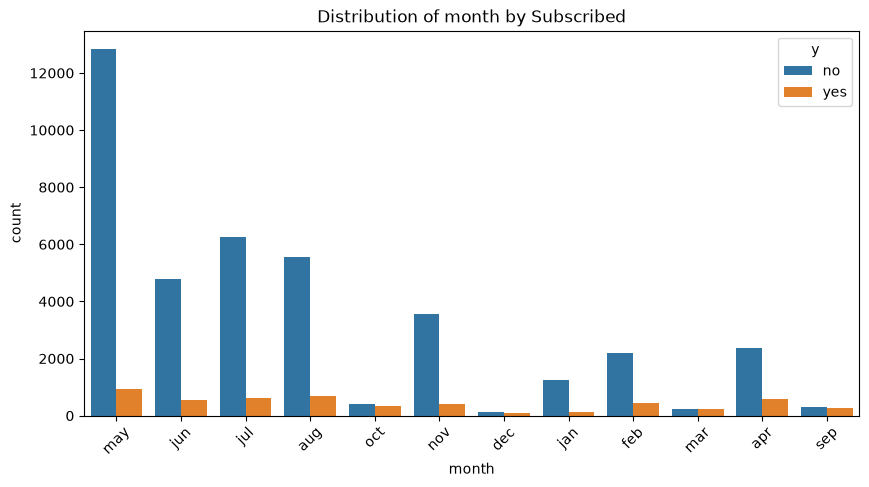

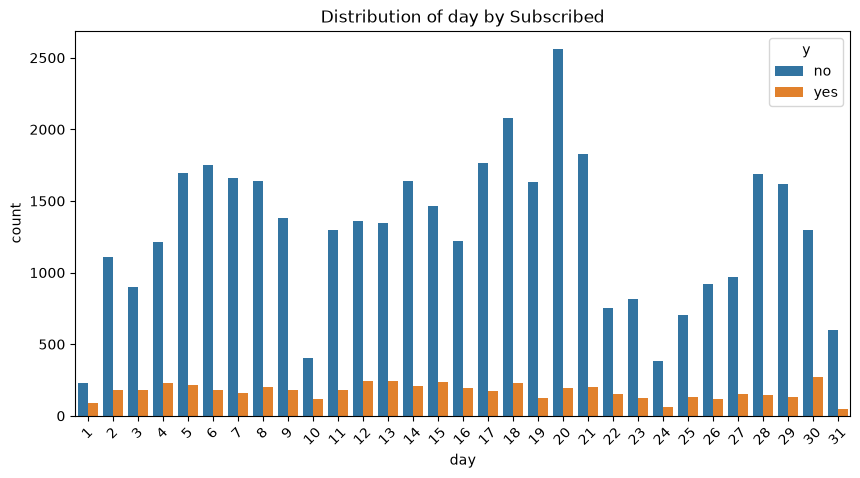

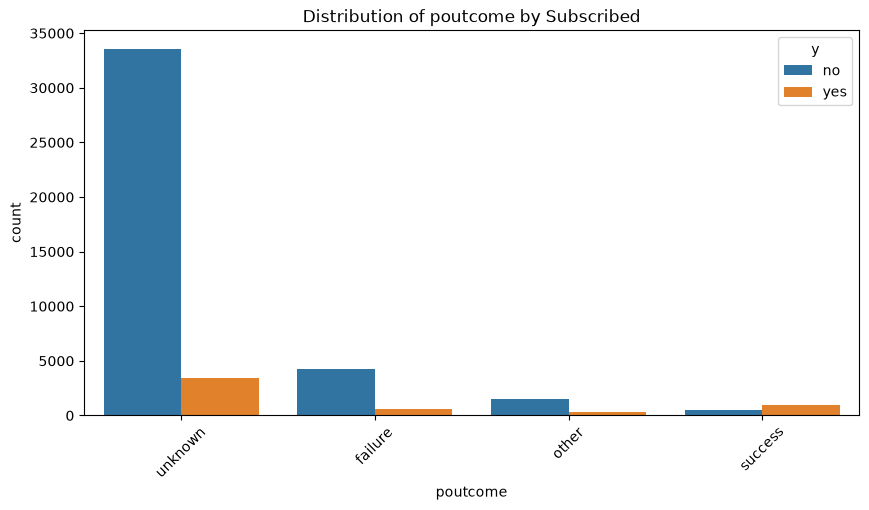

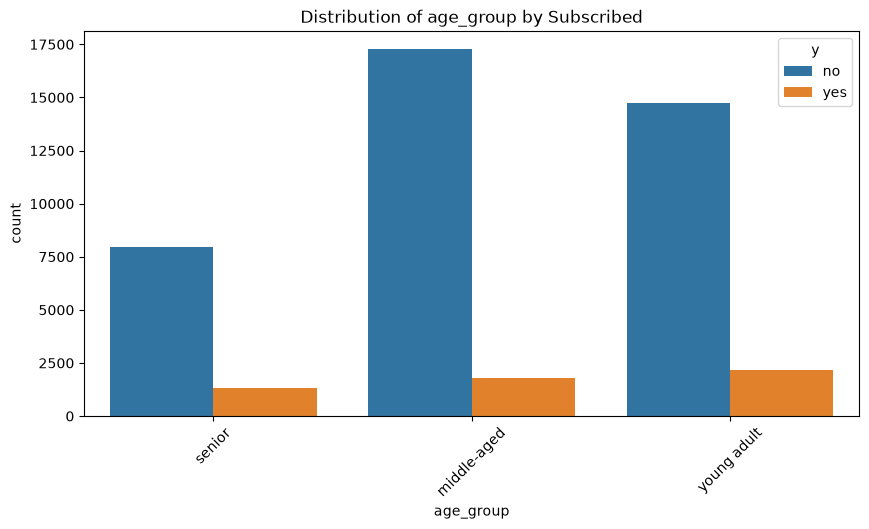

In [30]:
# Let's create bar plots for the categorical data

categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day', 'poutcome', 'age_group']
for features in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data = df, x = features, hue = 'y')
    plt.title(f'Distribution of {features} by Subscribed')
    plt.xticks(rotation=45)
    plt.show()

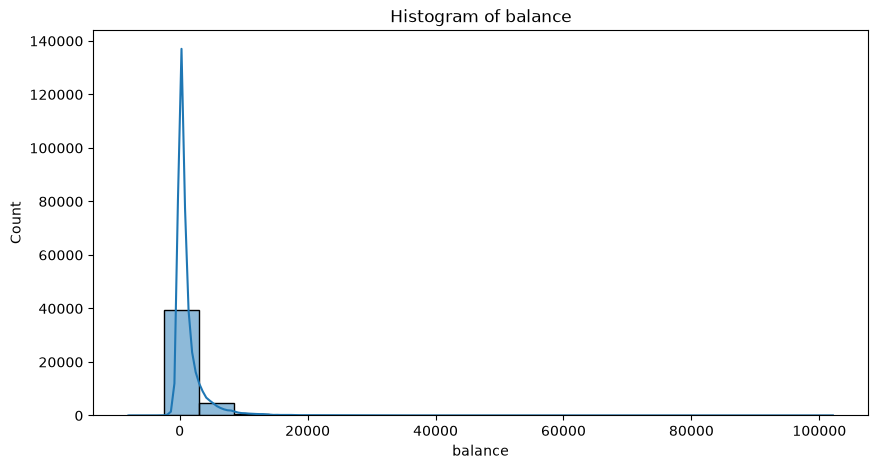

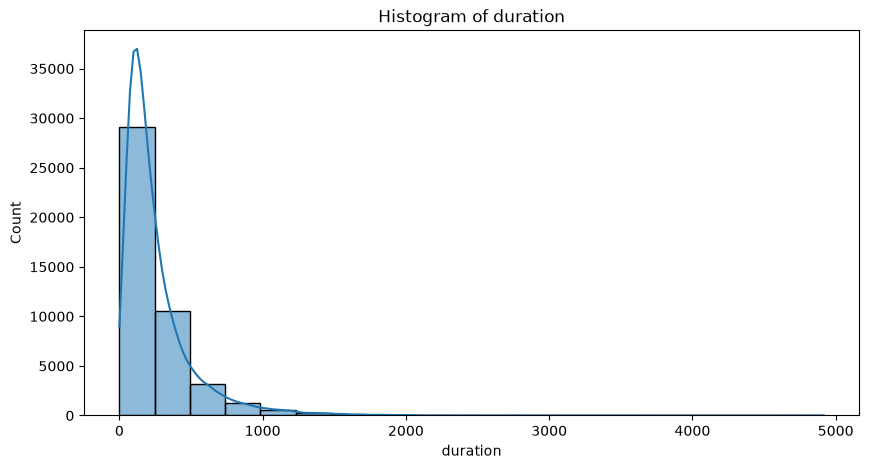

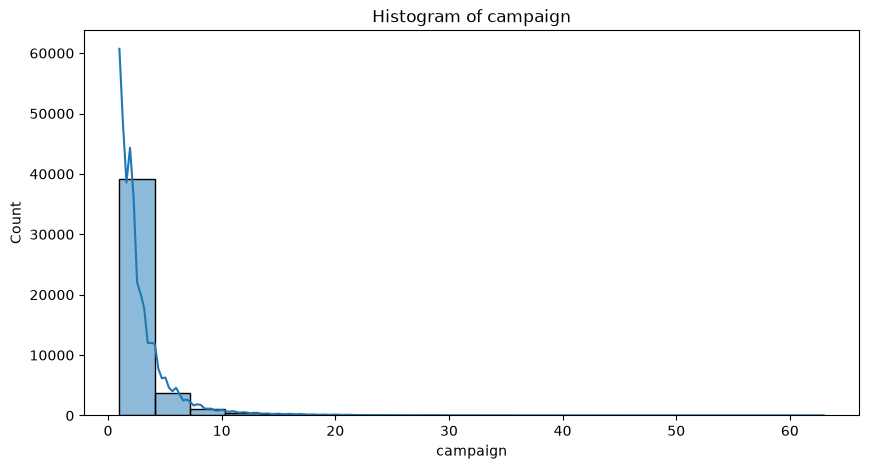

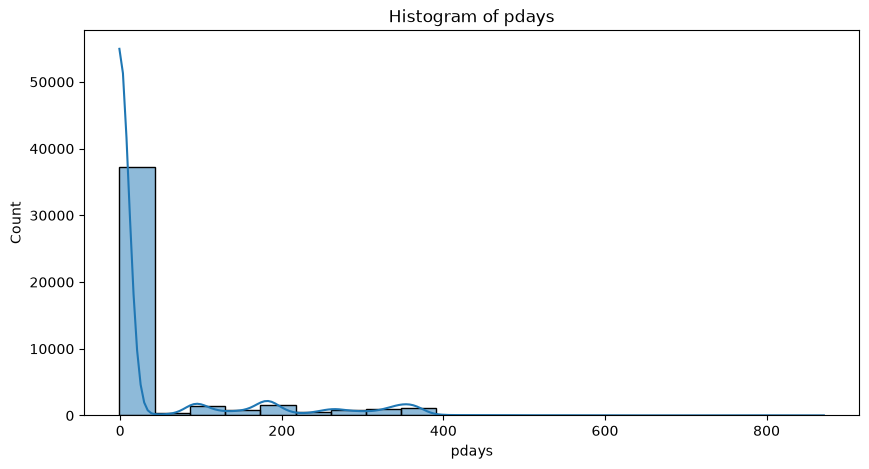

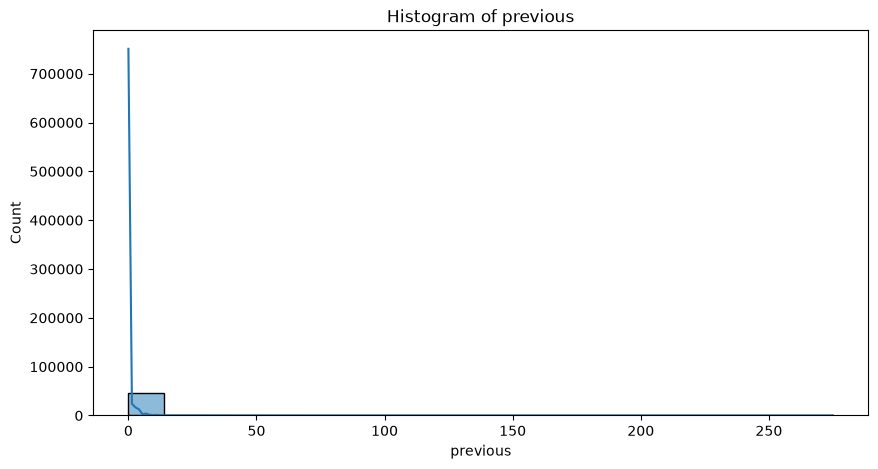

In [31]:
# Now let's create histograms for the numerical data

numerical_features = ['balance', 'duration', 'campaign', 'pdays', 'previous']
for features in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(data = df, x = features, bins=20, kde = True)
    plt.title(f'Histogram of {features}')
    plt.show()

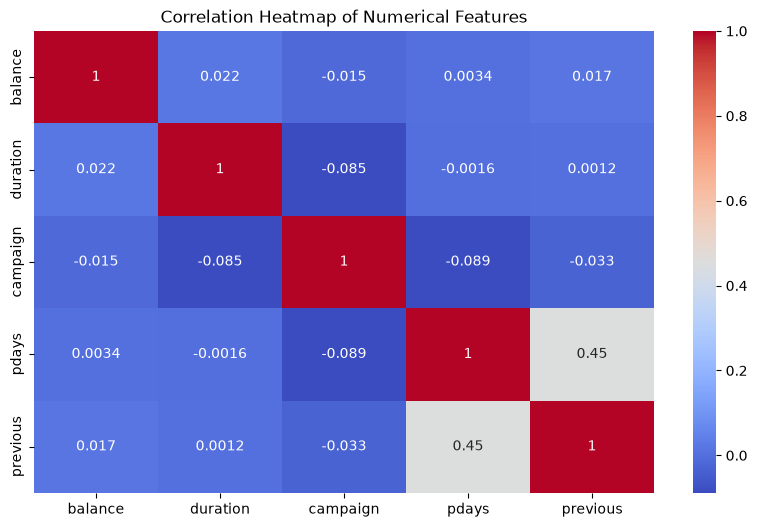

In [32]:
# Let's create a correlation heatmap displaying onl certain numerical features

correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(data = correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

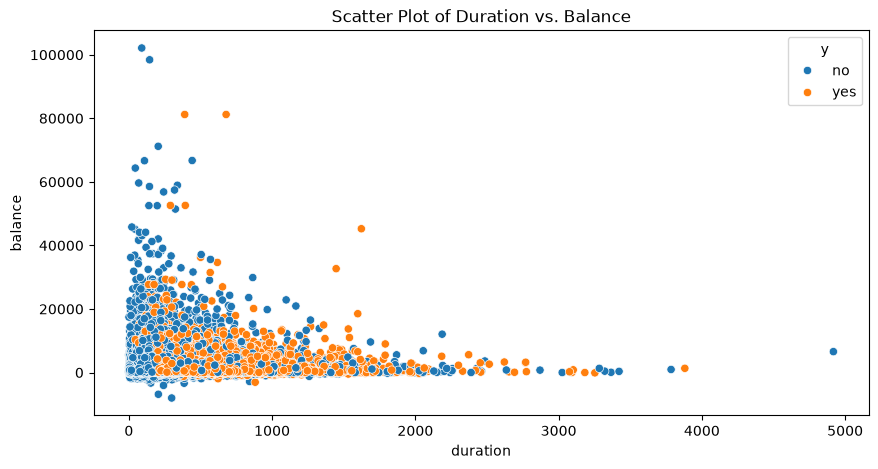

In [33]:
# Creating a scatter plot

plt.figure(figsize=(10, 5))
sns.scatterplot(data = df, x = 'duration', y = 'balance', hue = 'y')
plt.title('Scatter Plot of Duration vs. Balance')
plt.show()

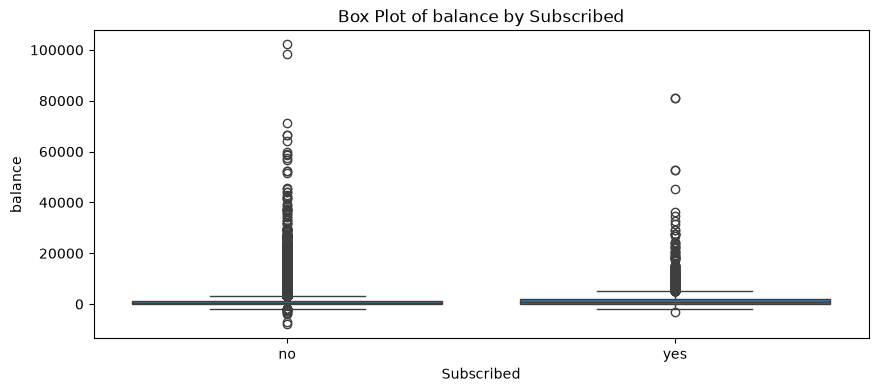

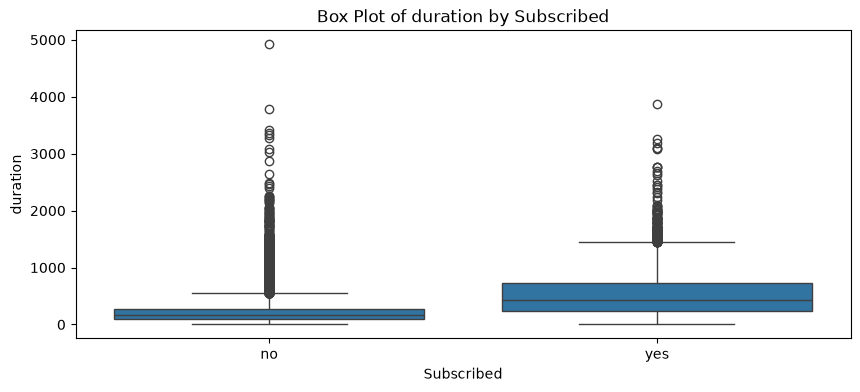

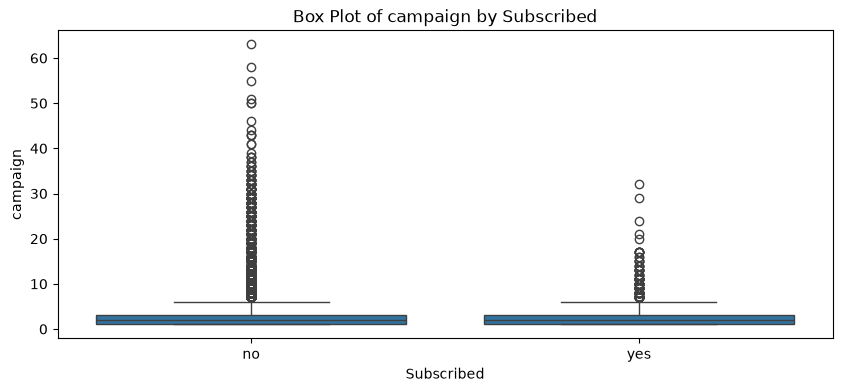

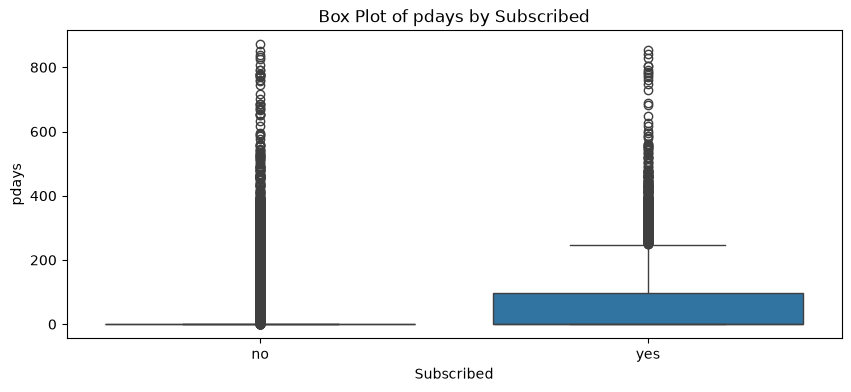

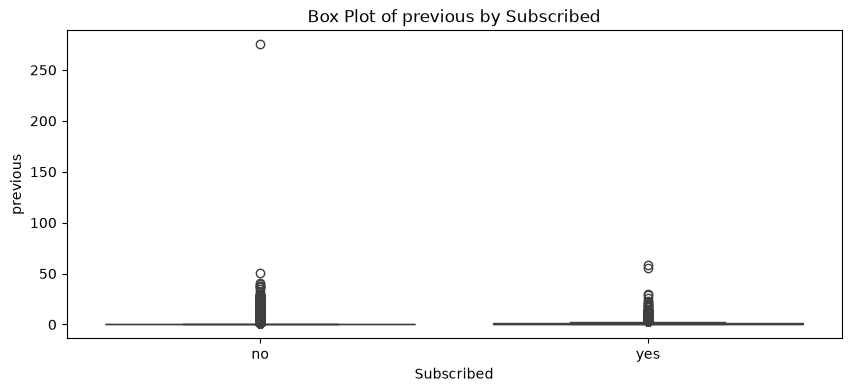

In [34]:
# Creating box plots

for features in numerical_features:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data = df, x = 'y', y = features)
    plt.title(f'Box Plot of {features} by Subscribed')
    plt.xlabel('Subscribed')
    plt.ylabel(features)
    plt.show()

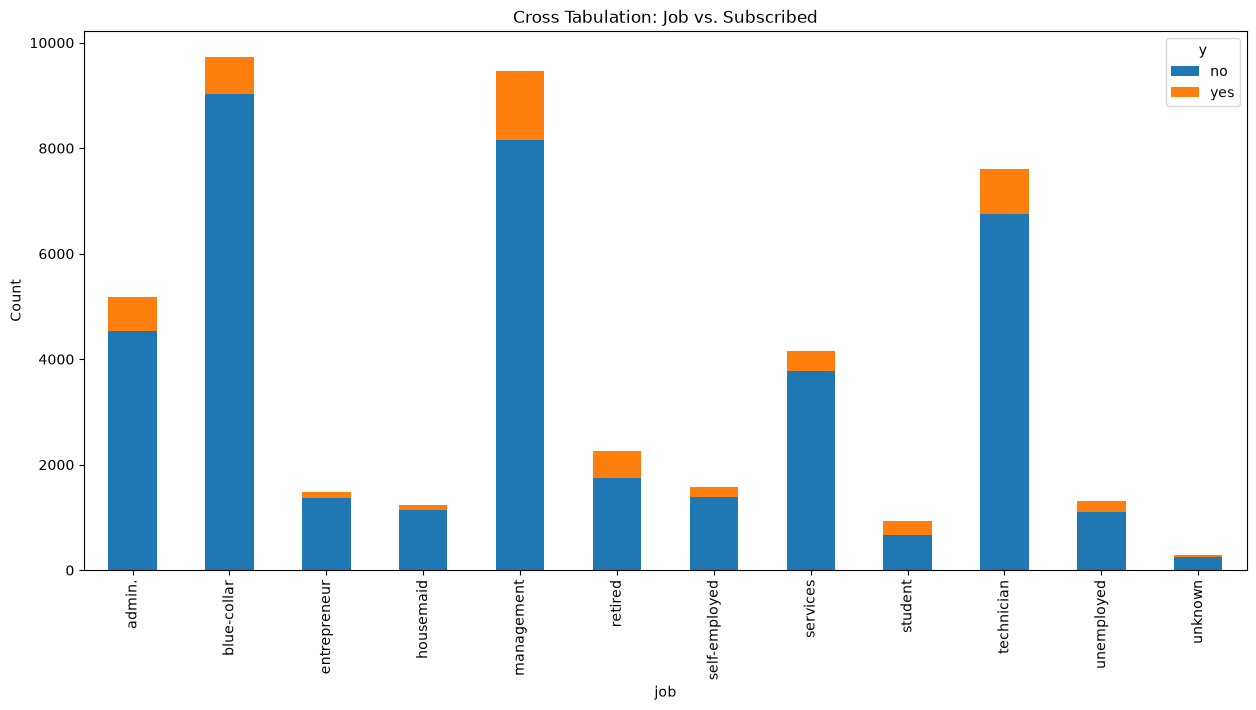

In [35]:
# Cross-tabulations for each job category

cross_tab = pd.crosstab(df['job'], df['y'])
cross_tab.plot(kind = 'bar', stacked = True, figsize = (15, 7))
plt.title('Cross Tabulation: Job vs. Subscribed')
plt.ylabel('Count')
plt.show()

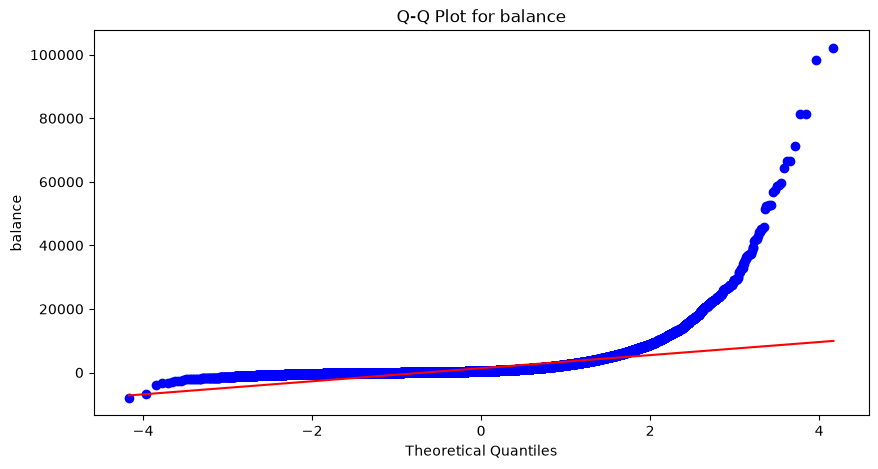

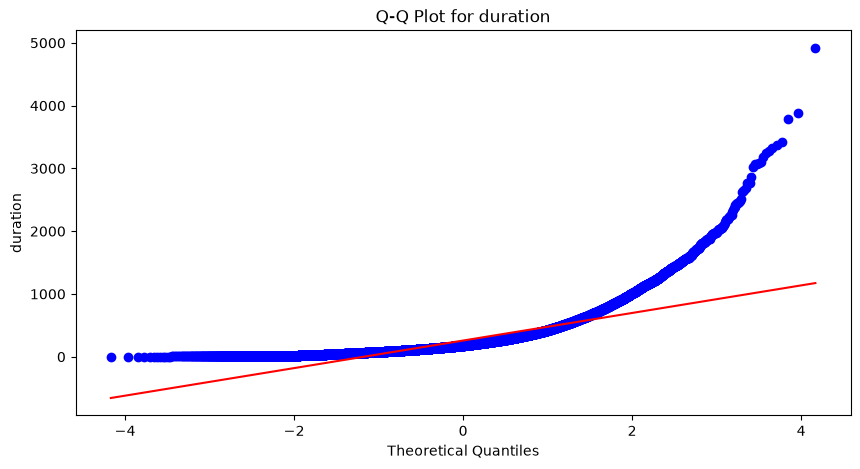

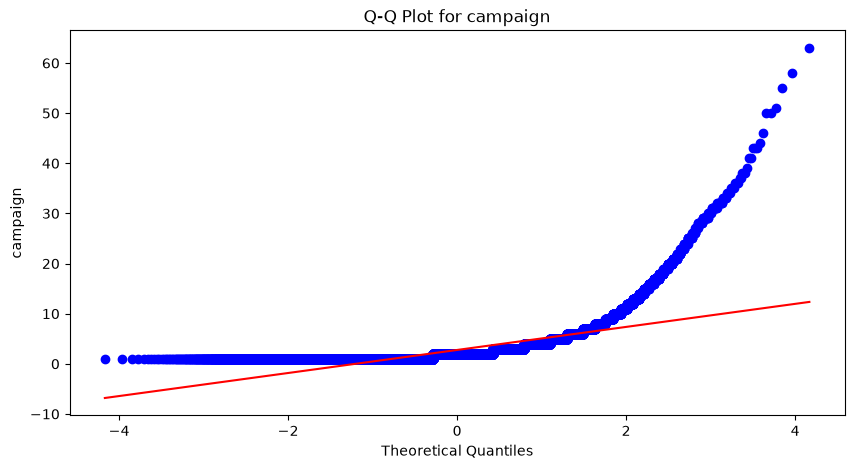

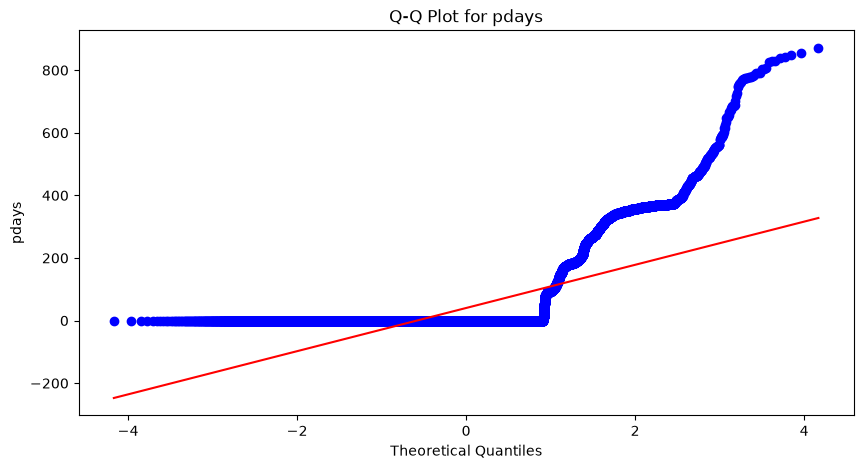

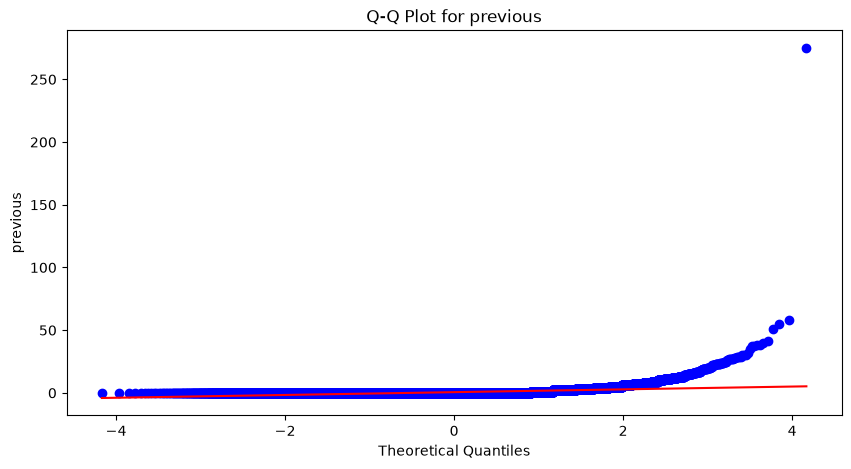

In [39]:
# This code automatically generates a Quantile-Quantile (Q-Q) plot for every numerical column
# to check if the data follows a normal distribution.

for feature in numerical_features:
    plt.figure(figsize=(10, 5))
    stats.probplot(df[feature], dist = "norm", plot = plt)
    plt.title(f'Q-Q Plot for {feature}')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel(feature)
    plt.show()

In [40]:
# There aren't any null values, but let's count the number of "unknown" values
# for each categorical feature

unknown_value_counts = (df == "unknown").sum()
unknown_value_counts

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
age_group        0
dtype: int64

In [44]:
# Let's check whether the dataset is balanced or imbalanced

# Calculate the class count of target variable
class_count = df.y.value_counts()

# Calculate the class count proportion of target variable
class_proportions = class_count / class_count.sum()

class_count

y
no     39922
yes     5289
Name: count, dtype: int64

In [42]:
class_proportions

y
no     0.883015
yes    0.116985
Name: count, dtype: float64

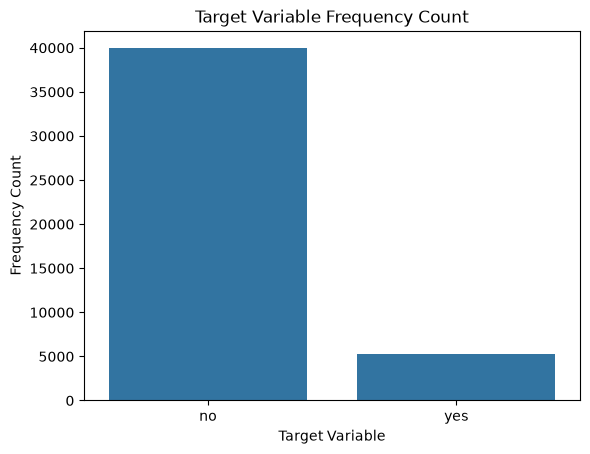

In [45]:
# Now let's graph the target value ('y') frequency

sns.countplot(data = df, x = "y")
plt.xlabel("Target Variable")
plt.ylabel("Frequency Count")
plt.title("Target Variable Frequency Count");

Clearly, this graph shows our dataset is very unbalanced - the number of "no" greatly outnumbers the "yes" in column 'y'. When the distribution of values is skewed like this, the trained model will have bias, which will negatively impact its performance.

In [47]:
# Let's encode the target variable

mapping = {"no":0, "yes":1}
df["target"] = df["y"].map(mapping)
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,age_group,target
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,senior,1
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,senior,1
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,senior,1
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,senior,0
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no,middle-aged,0


In [48]:
# We don't need the 'age' column, only the 'age group' column we created earlier.

df.drop(["y", "age"],axis = 1, inplace = True)

In [51]:
# Let's continue encoding categorical variables into numerics

nominal_columns = df.select_dtypes(include = "object").columns.tolist()

df_encoded = pd.get_dummies(df, columns = nominal_columns)
df_encoded.head()

C:\Users\Cyrus\AppData\Local\Temp\ipykernel_10168\2192807161.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  nominal_columns = df.select_dtypes(include = "object").columns.tolist()


,balance,day,duration,campaign,pdays,previous,target,job_admin.,job_blue-collar,job_entrepreneur,...,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,age_group_middle-aged,age_group_senior,age_group_young adult
0,2143,5,261,1,-1,0,0,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,29,5,151,1,-1,0,0,False,False,False,...,False,False,False,False,False,False,True,True,False,False
2,2,5,76,1,-1,0,0,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,1506,5,92,1,-1,0,0,False,True,False,...,False,False,False,False,False,False,True,True,False,False
4,1,5,198,1,-1,0,0,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [53]:
# Next, let's perform oversampling on the dataset to balance it

from imblearn.over_sampling import SMOTE
from collections import Counter

# Separate feature and target

x = df_encoded.drop("target", axis = 1)
y = df_encoded["target"]

# Instantiate SMOTE

smote = SMOTE()

# Perform oversampling
x_resampled, y_resampled = smote.fit_resample(x, y)

print("Class distribution before over sampling:", Counter(y))
print("Class distribution after over sampling:", Counter(y_resampled))

Class distribution before over sampling: Counter({0: 39922, 1: 5289})
Class distribution after over sampling: Counter({0: 39922, 1: 39922})


In [54]:
x_resampled.head()

,balance,day,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,age_group_middle-aged,age_group_senior,age_group_young adult
0,2143,5,261,1,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,29,5,151,1,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
2,2,5,76,1,-1,0,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,1506,5,92,1,-1,0,False,True,False,False,...,False,False,False,False,False,False,True,True,False,False
4,1,5,198,1,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [55]:
y_resampled.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [ ]:
# This will split the dataset into training and testing subsets and imports a tool for tuning model settings
# Splitting data prevents overfitting. Testing a model on the same data used to train it creates a false sense of accuracy.
# Using a separate test set proves whether the model can generalize to real-world data.

from sklearn.model_selection import train_test_split, GridSearchCV
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, random_state = 45, test_size = 0.25)

In [57]:
x_train

,balance,day,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,age_group_middle-aged,age_group_senior,age_group_young adult
4526,2007,20,253,1,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4623,410,20,112,2,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
58897,1450,30,277,2,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
50389,-15,4,138,2,95,8,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
78113,0,23,212,1,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12895,85,7,88,1,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
60960,5396,22,244,1,92,2,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
6012,576,26,158,4,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
63107,2509,17,674,3,-1,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [58]:
y_train

4526     0
4623     0
58897    1
50389    1
78113    1
        ..
12895    0
60960    1
6012     0
63107    1
6558     0
Name: target, Length: 59883, dtype: int64

In [ ]:
# We will need some more ML tools and modules

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

## Decision Tree Model

In [75]:
decisionTree = DecisionTreeClassifier()
decisionTree.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
# Let's test our 'Decision Tree' model. scikit-learn returns the mean accuracy of the model on the given test data

decisionTree.score(x_test,y_test)

0.9259556134462201

## Random Forest Model

In [74]:
randomForest = RandomForestClassifier(n_estimators=1000,n_jobs=-1)
randomForest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bo

In [76]:
# Let's test our 'Decision Tree' model

randomForest.score(x_test, y_test)

0.9498522118130355

In [78]:
# Let's standardize the features

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

## Naive Bayes Model

In [79]:
# Naive Bayes Algorithm

nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)
y_pred_nb = nb_model.predict(x_test_scaled)
print("\nNaive Bayes (Gaussian):")
print(classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))


Naive Bayes (Gaussian):
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     10014
           1       0.90      0.87      0.89      9947

    accuracy                           0.89     19961
   macro avg       0.89      0.89      0.89     19961
weighted avg       0.89      0.89      0.89     19961

Accuracy: 0.8886829317168479


## Logistic Regression Model

In [80]:
# Logistic Regression

lr_model = LogisticRegression()
lr_params = {'C': [0.01, 0.1, 1, 10]}
lr_grid = GridSearchCV(lr_model, lr_params, cv = 5)
lr_grid.fit(x_train_scaled, y_train)
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(x_test_scaled)
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     10014
           1       0.97      0.91      0.94      9947

    accuracy                           0.94     19961
   macro avg       0.95      0.94      0.94     19961
weighted avg       0.95      0.94      0.94     19961

Accuracy: 0.9439406843344522


## K-Nearest Neighbours

In [ ]:
# K-Nearest Neighbors

knn_model = KNeighborsClassifier(weights='distance',algorithm='kd_tree',n_jobs=-1)
knn_params = {'n_neighbors': [3, 5, 7], 'p': [1, 2]}
knn_grid = GridSearchCV(knn_model, knn_params, cv=5)
knn_grid.fit(x_train_scaled, y_train)
knn_best = knn_grid.best_estimator_
y_pred_knn = knn_best.predict(x_test_scaled)
print("\nK-Nearest Neighbors (Weighted Distance):")
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

## Graphing the Results of Each Model

c:\Users\Cyrus\Documents\Assignments\Python\Bank Marketing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


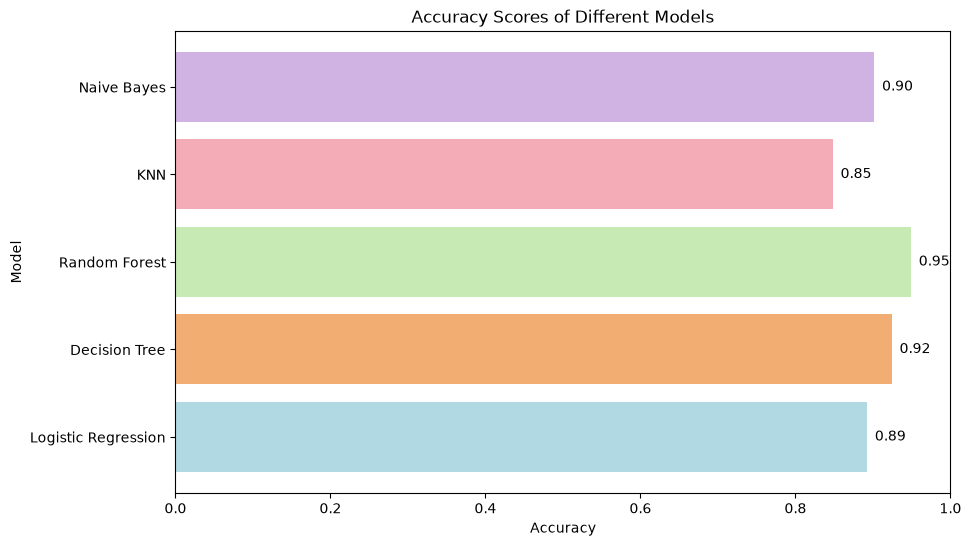

In [93]:
# Let's create a dictionary to store models and their names

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
}

# Initialize lists to store model names and accuracy scores

model_names = []
accuracy_scores = []

# Loop through each model, train, predict, and store accuracy

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    model_names.append(name)
    accuracy_scores.append(accuracy)

# Define colors for each bar
colors = ['#b0d9e4', '#f2ae72', '#c7e9b4', '#f4acb7', '#d0b3e3']

# Plot the accuracy scores
plt.figure(figsize=(10, 6))
plt.barh(model_names, accuracy_scores, color = colors)
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Accuracy Scores of Different Models')
plt.xlim(0, 1)  # Set x-axis limit to better visualize differences

# Label the accuracy scores on the bars
for i, acc in enumerate(accuracy_scores):
    plt.text(acc + 0.01, i, f'{acc:.2f}', va = 'center')

plt.show()

We have now completed our task of building a predictive model to determine whether a customer will open a term deposit. Based on the results shown above, we would want to choose the 'Random Forest' model since it has the highest accuracy at almost 95%.